In [1]:
import pandas as pd

df = pd.read_csv("/home/ubuntu/vonwald.github.io/data/lightcast_job_postings.csv")

print(df.shape)
print(df.columns.tolist())

/tmp/ipykernel_6146/1287297593.py:3: DtypeWarning: Columns (0: COMPANY_IS_STAFFING, 1: IS_INTERNSHIP) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/ubuntu/vonwald.github.io/data/lightcast_job_postings.csv")


(72498, 131)
['ID', 'LAST_UPDATED_DATE', 'LAST_UPDATED_TIMESTAMP', 'DUPLICATES', 'POSTED', 'EXPIRED', 'DURATION', 'SOURCE_TYPES', 'SOURCES', 'URL', 'ACTIVE_URLS', 'ACTIVE_SOURCES_INFO', 'TITLE_RAW', 'BODY', 'MODELED_EXPIRED', 'MODELED_DURATION', 'COMPANY', 'COMPANY_NAME', 'COMPANY_RAW', 'COMPANY_IS_STAFFING', 'EDUCATION_LEVELS', 'EDUCATION_LEVELS_NAME', 'MIN_EDULEVELS', 'MIN_EDULEVELS_NAME', 'MAX_EDULEVELS', 'MAX_EDULEVELS_NAME', 'EMPLOYMENT_TYPE', 'EMPLOYMENT_TYPE_NAME', 'MIN_YEARS_EXPERIENCE', 'MAX_YEARS_EXPERIENCE', 'IS_INTERNSHIP', 'SALARY', 'REMOTE_TYPE', 'REMOTE_TYPE_NAME', 'ORIGINAL_PAY_PERIOD', 'SALARY_TO', 'SALARY_FROM', 'LOCATION', 'CITY', 'CITY_NAME', 'COUNTY', 'COUNTY_NAME', 'MSA', 'MSA_NAME', 'STATE', 'STATE_NAME', 'COUNTY_OUTGOING', 'COUNTY_NAME_OUTGOING', 'COUNTY_INCOMING', 'COUNTY_NAME_INCOMING', 'MSA_OUTGOING', 'MSA_NAME_OUTGOING', 'MSA_INCOMING', 'MSA_NAME_INCOMING', 'NAICS2', 'NAICS2_NAME', 'NAICS3', 'NAICS3_NAME', 'NAICS4', 'NAICS4_NAME', 'NAICS5', 'NAICS5_NAME', 'N

In [2]:
columns_to_drop = [
    "LAST_UPDATED_DATE",
    "LAST_UPDATED_TIMESTAMP",
    "DUPLICATES",
    "SOURCE_TYPES",
    "SOURCES",
    "URL",
    "ACTIVE_URLS",
    "ACTIVE_SOURCES_INFO",
    "BODY",
    "COMPANY_RAW",
    "ORIGINAL_PAY_PERIOD",
    "LOCATION",
    "CITY",
    "CITY_NAME",
    "COUNTY",
    "COUNTY_NAME",
    "MSA",
    "MSA_NAME",
    "STATE",
    "STATE_NAME",
    "COUNTY_OUTGOING",
    "COUNTY_NAME_OUTGOING",
    "COUNTY_INCOMING",
    "COUNTY_NAME_INCOMING",
    "MSA_OUTGOING",
    "MSA_NAME_OUTGOING",
    "MSA_INCOMING",
    "MSA_NAME_INCOMING",
    "NAICS3",
    "NAICS3_NAME",
    "NAICS4",
    "NAICS4_NAME",
    "NAICS5",
    "NAICS5_NAME",
    "NAICS6",
    "NAICS6_NAME",
    "CIP6",
    "CIP6_NAME",
    "CIP4",
    "CIP4_NAME",
    "CIP2",
    "NAICS_2022_2",
    "NAICS_2022_2_NAME",
    "NAICS_2022_3",
    "NAICS_2022_3_NAME",
    "NAICS_2022_4",
    "NAICS_2022_4_NAME",
    "NAICS_2022_5",
    "NAICS_2022_5_NAME",
    "NAICS_2022_6",
    "NAICS_2022_6_NAME"
]

In [3]:
missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print(missing_summary.head(30))

ACTIVE_SOURCES_INFO           64680
MAX_YEARS_EXPERIENCE          64068
MAX_EDULEVELS_NAME            56183
MAX_EDULEVELS                 56183
LIGHTCAST_SECTORS             54711
LIGHTCAST_SECTORS_NAME        54711
SALARY                        41690
SALARY_FROM                   40100
SALARY_TO                     40100
ORIGINAL_PAY_PERIOD           40100
DURATION                      27316
MIN_YEARS_EXPERIENCE          23146
MODELED_DURATION              19290
MODELED_EXPIRED               15416
EXPIRED                        7844
MSA_INCOMING                   3962
MSA_NAME_INCOMING              3962
MSA_NAME                       3949
MSA                            3949
MSA_NAME_OUTGOING              3949
MSA_OUTGOING                   3949
COMPANY_RAW                     541
TITLE_CLEAN                     140
TITLE_RAW                       104
LOT_OCCUPATION_NAME              44
LOT_SPECIALIZED_OCCUPATION       44
LOT_OCCUPATION                   44
EMPLOYMENT_TYPE             

In [4]:
missing_percent = (df.isnull().sum() / len(df) * 100)

missing_percent = (
    missing_percent[missing_percent > 0]
    .sort_values(ascending=False)
)

print(missing_percent.head(30))

ACTIVE_SOURCES_INFO           89.216254
MAX_YEARS_EXPERIENCE          88.372093
MAX_EDULEVELS_NAME            77.495931
MAX_EDULEVELS                 77.495931
LIGHTCAST_SECTORS             75.465530
LIGHTCAST_SECTORS_NAME        75.465530
SALARY                        57.505035
SALARY_FROM                   55.311871
SALARY_TO                     55.311871
ORIGINAL_PAY_PERIOD           55.311871
DURATION                      37.678281
MIN_YEARS_EXPERIENCE          31.926398
MODELED_DURATION              26.607631
MODELED_EXPIRED               21.264035
EXPIRED                       10.819609
MSA_INCOMING                   5.464978
MSA_NAME_INCOMING              5.464978
MSA_NAME                       5.447047
MSA                            5.447047
MSA_NAME_OUTGOING              5.447047
MSA_OUTGOING                   5.447047
COMPANY_RAW                    0.746227
TITLE_CLEAN                    0.193109
TITLE_RAW                      0.143452
LOT_OCCUPATION_NAME            0.060691


In [5]:
pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)
Note: you may need to restart the kernel to use updated packages.


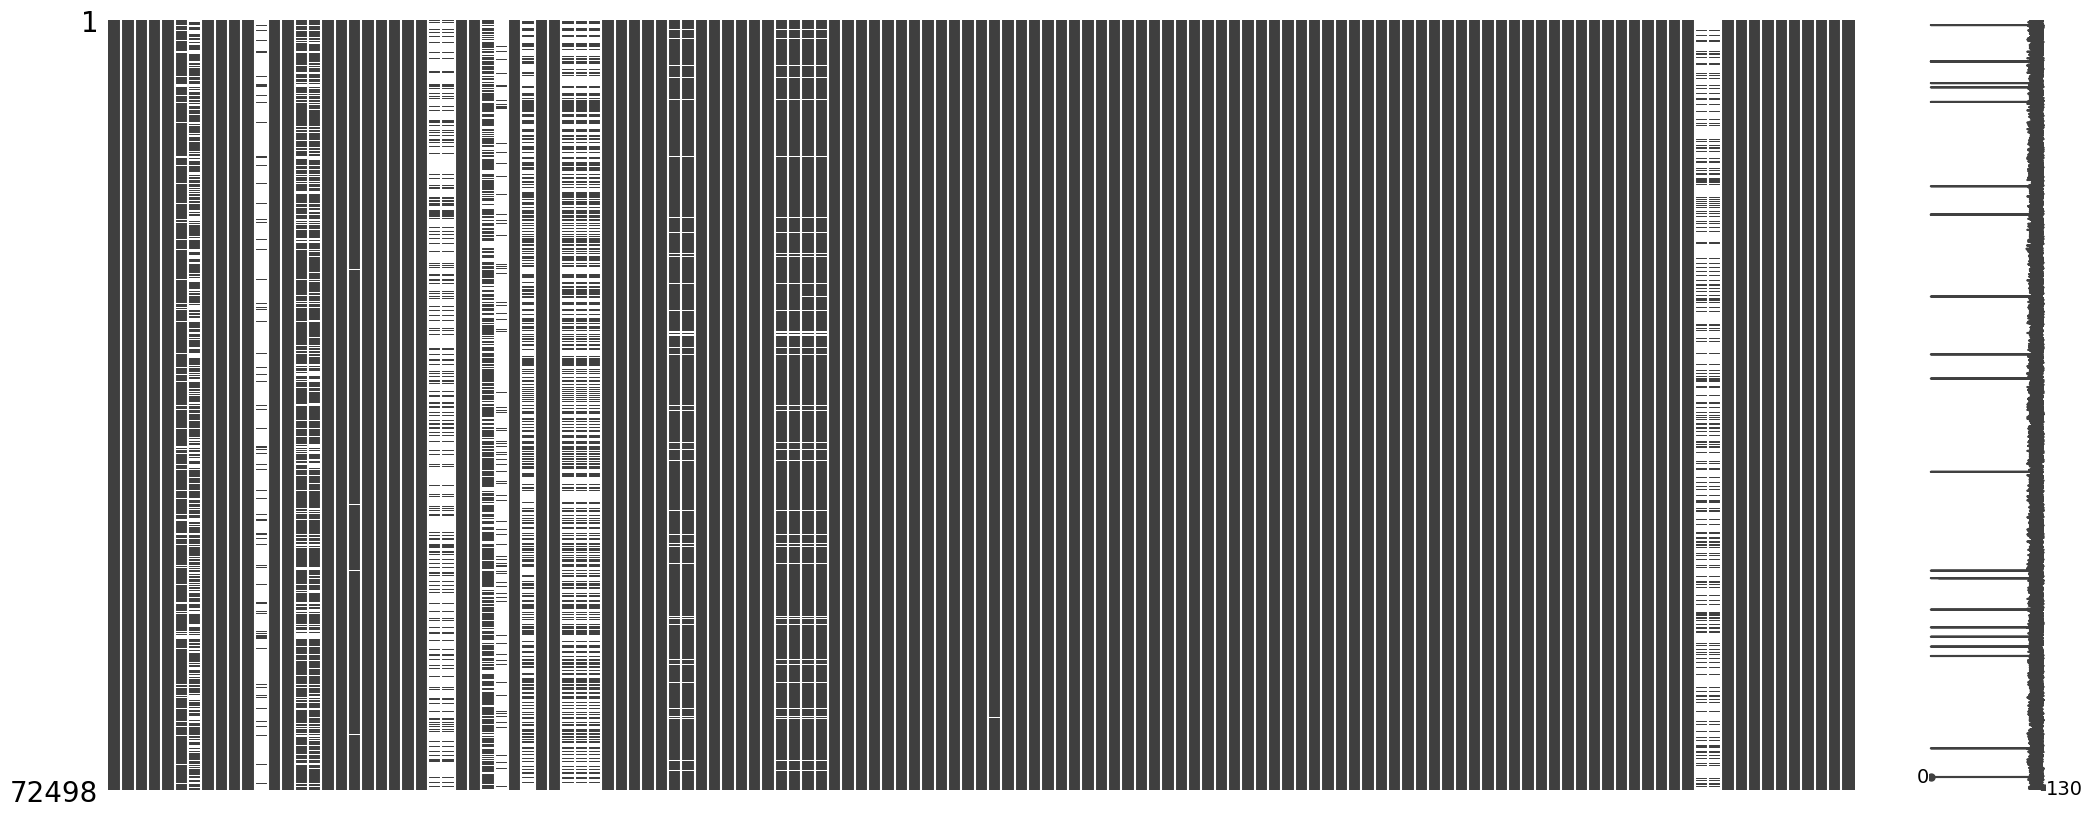

In [6]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.show()

In [7]:
cols_over_50 = [
    "ACTIVE_SOURCES_INFO",
    "MAX_YEARS_EXPERIENCE",
    "MAX_EDULEVELS_NAME",
    "MAX_EDULEVELS",
    "LIGHTCAST_SECTORS",
    "LIGHTCAST_SECTORS_NAME",
    "SALARY",
    "SALARY_FROM",
    "SALARY_TO",
    "ORIGINAL_PAY_PERIOD"
]

In [8]:
df = df.drop(columns=cols_over_50)

print(df.shape)

(72498, 121)


In [9]:
numeric_cols = df.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
categorical_cols = df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

/tmp/ipykernel_6146/1590413863.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


In [11]:
print(df.isnull().sum().sum())

0


In [12]:
before = len(df)

df = df.drop_duplicates(
    subset=["TITLE", "COMPANY", "LOCATION", "POSTED"],
    keep="first"
)

after = len(df)

print(f"Removed {before - after} duplicates")
print(df.shape)

Removed 3300 duplicates
(69198, 121)


In [13]:
df.to_csv("cleaned_lightcast_jobs.csv", index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.
